# Taller: Z-Buffer y Depth Testing
## Notebook 1 — Painter's Algorithm vs Z-Buffer

Este notebook cubre:
- **Sección 1:** Proyección 3D→2D y renderizado sin Z-buffer (Painter's Algorithm)
- **Sección 2:** Implementación del Z-buffer desde cero
- **Sección 3:** Comparación lado a lado con/sin Z-buffer

---
## Setup — Imports y utilidades base

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image

#Parámetros globales de la imagen 
WIDTH  = 512
HEIGHT = 512

print(f"Canvas: {WIDTH}x{HEIGHT} px")

Canvas: 512x512 px


---
## Sección 1 — Renderizado sin Z-Buffer (Painter's Algorithm)

### 1.1 Función de proyección perspectiva 3D → 2D

La proyección perspectiva divide las coordenadas X e Y por la profundidad Z,
creando el efecto de que los objetos más lejanos parecen más pequeños:

$$x_{2D} = \frac{f \cdot x_{3D}}{z_{3D}} + c_x, \quad y_{2D} = \frac{f \cdot y_{3D}}{z_{3D}} + c_y$$

In [14]:
def project_point(point3d, focal_length=500, cx=WIDTH//2, cy=HEIGHT//2):
    """
    Proyecta un punto 3D (x, y, z) a coordenadas de pantalla 2D (px, py)
    usando proyección perspectiva.
    
    Retorna: (px, py) en píxeles de pantalla
    """
    x, y, z = point3d
    if z <= 0:
        z = 0.001  # evitar división por cero
    px = int(focal_length * x / z + cx)
    py = int(focal_length * y / z + cy)
    return px, py


def project_triangle(triangle3d, focal_length=500):
    """
    Proyecta los 3 vértices de un triángulo 3D a 2D.
    
    triangle3d: lista de 3 puntos [(x,y,z), (x,y,z), (x,y,z)]
    Retorna: lista de 3 puntos 2D [(px,py), ...]
    """
    return [project_point(v, focal_length) for v in triangle3d]


# Verificación visual de la proyección 
test_points = [
    (0.0,  0.0, 2.0),   # centro, z=2
    (1.0,  0.0, 2.0),   # derecha, z=2
    (1.0,  0.0, 4.0),   # derecha, z=4 (más lejos → más cerca del centro)
]

print("Proyecciones de prueba:")
for p in test_points:
    proj = project_point(p)
    print(f"  3D {p}  →  2D {proj}")

Proyecciones de prueba:
  3D (0.0, 0.0, 2.0)  →  2D (256, 256)
  3D (1.0, 0.0, 2.0)  →  2D (506, 256)
  3D (1.0, 0.0, 4.0)  →  2D (381, 256)


### 1.2 Rasterización de triángulos (Barycentric coordinates)

Para rellenar un triángulo píxel a píxel usamos **coordenadas baricéntricas**.
Un punto $P$ está dentro del triángulo $ABC$ si:

$$\lambda_0 \geq 0, \quad \lambda_1 \geq 0, \quad \lambda_2 \geq 0, \quad \lambda_0 + \lambda_1 + \lambda_2 = 1$$

Estas mismas coordenadas se usan para **interpolar la profundidad Z** de cada píxel.

In [15]:
def edge_function(a, b, p):
    """Función de arista: determina el lado del punto p respecto al segmento a→b."""
    return (p[0] - a[0]) * (b[1] - a[1]) - (p[1] - a[1]) * (b[0] - a[0])


def rasterize_triangle_painter(color_buffer, triangle2d, color):
    """
    Rasteriza un triángulo 2D directamente sobre color_buffer.
    Sin Z-buffer: sobreescribe todo lo que haya (Painter's Algorithm).
    
    color_buffer : array (H, W, 3) uint8
    triangle2d   : [(x0,y0), (x1,y1), (x2,y2)] en píxeles
    color        : (R, G, B) uint8
    """
    p0, p1, p2 = triangle2d

    # Bounding box recortada al canvas
    min_x = max(0, min(p0[0], p1[0], p2[0]))
    max_x = min(WIDTH  - 1, max(p0[0], p1[0], p2[0]))
    min_y = max(0, min(p0[1], p1[1], p2[1]))
    max_y = min(HEIGHT - 1, max(p0[1], p1[1], p2[1]))

    area = edge_function(p0, p1, p2)
    if area == 0:
        return  # triángulo degenerado

    for y in range(min_y, max_y + 1):
        for x in range(min_x, max_x + 1):
            p = (x, y)
            w0 = edge_function(p1, p2, p)
            w1 = edge_function(p2, p0, p)
            w2 = edge_function(p0, p1, p)

            # Mismo signo → el punto está dentro del triángulo
            if (w0 >= 0 and w1 >= 0 and w2 >= 0) or (w0 <= 0 and w1 <= 0 and w2 <= 0):
                color_buffer[y, x] = color



### 1.3 Escena de prueba y demostración del problema del Painter's Algorithm

El **Painter's Algorithm** pinta los triángulos de atrás hacia adelante.
**Problema:** si dos triángulos se solapan cíclicamente, no existe un orden correcto.

In [16]:
#  Definición de la escena 3D 
# Cada triángulo = lista de 3 vértices (x, y, z) + color RGB
# z positivo = más lejos de la cámara

scene_triangles = [
    # (vértices 3D,                                           color RGB,          nombre)
    # Triángulo ROJO — centrado, z moderado
    ([(-0.6, -0.5, 2.5), (0.6, -0.5, 2.5), (0.0,  0.6, 2.5)],  (220,  50,  50), "Rojo   z=2.5"),
    # Triángulo AZUL — desplazado, más cercano en parte
    ([(-0.2, -0.6, 2.0), (0.8, -0.1, 3.0), (0.0,  0.5, 2.2)],  ( 50,  80, 220), "Azul   z≈2-3"),
    # Triángulo VERDE — fondo, más lejano
    ([(-0.9,  0.3, 3.5), (0.2, -0.7, 3.5), (0.5,  0.7, 3.5)],  ( 50, 200,  80), "Verde  z=3.5"),
    # Triángulo AMARILLO — solapado, mismo z-range que rojo/azul → problema claro
    ([(-0.4,  0.1, 2.3), (0.7,  0.1, 2.8), (0.15,-0.6, 2.6)],  (230, 200,  30), "Amarillo z≈2.3-2.8"),
]

def average_z(triangle3d):
    """Z promedio de un triángulo (usado para ordenar en Painter's Algorithm)."""
    return sum(v[2] for v in triangle3d) / 3.0


def render_painter(triangles, focal_length=500):
    """
    Renderiza la escena usando Painter's Algorithm:
    ordena por Z promedio (de mayor a menor) y pinta en ese orden.
    """
    color_buffer = np.zeros((HEIGHT, WIDTH, 3), dtype=np.uint8)

    # Ordenar de más lejano (mayor Z) a más cercano (menor Z)
    sorted_tris = sorted(triangles, key=lambda t: average_z(t[0]), reverse=True)

    for verts3d, color, name in sorted_tris:
        verts2d = project_triangle(verts3d, focal_length)
        rasterize_triangle_painter(color_buffer, verts2d, color)
        print(f"  Pintado: {name}  (z_avg={average_z(verts3d):.2f})")

    return color_buffer


painter_result = render_painter(scene_triangles)

  Pintado: Verde  z=3.5  (z_avg=3.50)
  Pintado: Amarillo z≈2.3-2.8  (z_avg=2.57)
  Pintado: Rojo   z=2.5  (z_avg=2.50)
  Pintado: Azul   z≈2-3  (z_avg=2.40)


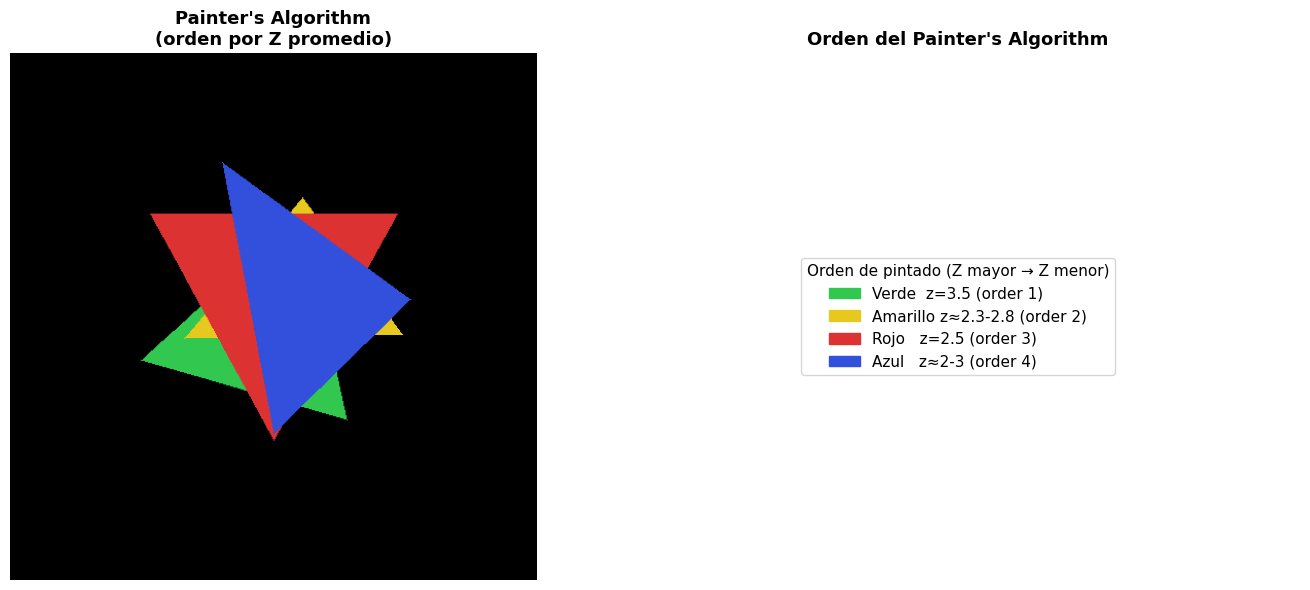

Imagen guardada: painter_result.png


In [ ]:
#  Visualización del resultado 
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Resultado renderizado
axes[0].imshow(painter_result)
axes[0].set_title("Painter's Algorithm\n(orden por Z promedio)", fontsize=13, fontweight='bold')
axes[0].axis('off')

# Diagrama explicativo del orden de pintado
legend_items = [
    mpatches.Patch(color=np.array(c)/255, label=f"{n} (order {i+1})")
    for i, (_, c, n) in enumerate(
        sorted(scene_triangles, key=lambda t: average_z(t[0]), reverse=True)
    )
]
axes[1].set_facecolor('#f0f0f0')
axes[1].legend(handles=legend_items, loc='center', fontsize=11,
               title="Orden de pintado (Z mayor → Z menor)", title_fontsize=11)
axes[1].set_title("Orden del Painter's Algorithm", fontsize=13, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.savefig('painter_result.png', dpi=150, bbox_inches='tight')
plt.show()

### 1.4 Demostración explícita del fallo del Painter's Algorithm

Con objetos que se solapan cíclicamente (A tapa a B, B tapa a C, C tapa a A),
**ningún orden de pintado produce el resultado correcto**.

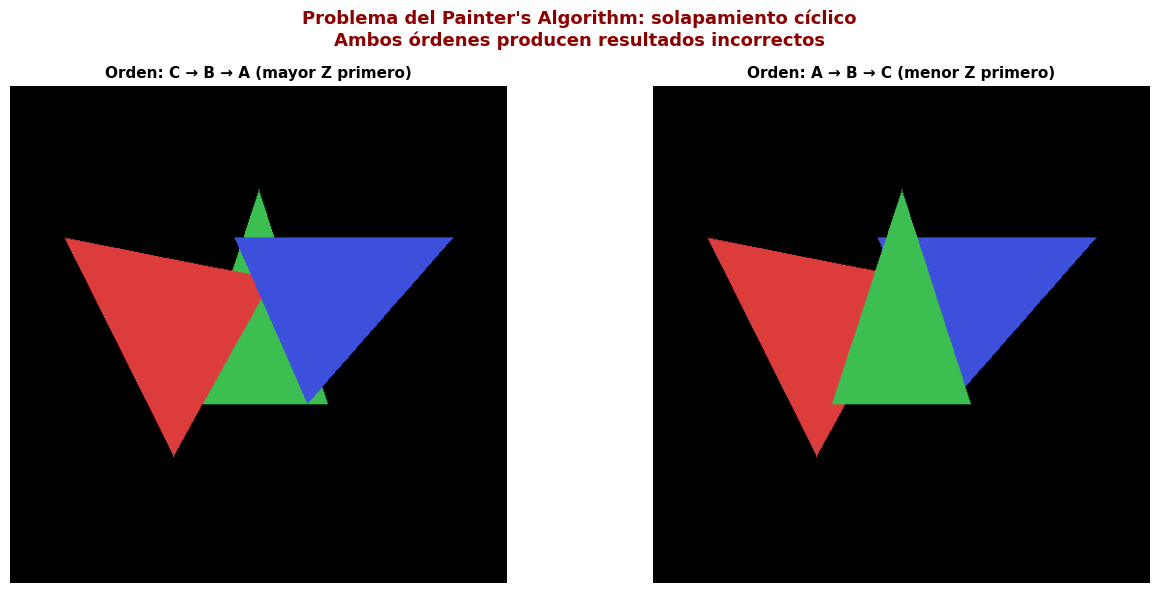

In [18]:
# ─── Escena con solapamiento cíclico ────────────────────────────────────────
cyclic_triangles = [
    # Triángulo A (Rojo): izquierda, cruza por delante de B
    ([(-0.8, -0.4, 2.0), ( 0.1, -0.4, 3.5), (-0.35,  0.5, 2.0)], (220, 60, 60),   "A-Rojo"),
    # Triángulo B (Azul): derecha, cruza por delante de C
    ([(-0.1, -0.4, 2.0), ( 0.8, -0.4, 2.0), ( 0.35,  0.5, 3.5)], (60, 80, 220),   "B-Azul"),
    # Triángulo C (Verde): abajo, cruza por delante de A
    ([(-0.5,  0.5, 3.5), ( 0.5,  0.5, 3.5), ( 0.0, -0.6, 2.0)], (60, 190, 80),   "C-Verde"),
]

# Renderizar en AMBOS órdenes para mostrar el problema
fig, axes = plt.subplots(1, 2, figsize=(13, 6))

for ax, reverse_order, title_txt in [
    (axes[0], True,  "Orden: C → B → A (mayor Z primero)"),
    (axes[1], False, "Orden: A → B → C (menor Z primero)"),
]:
    buf = np.zeros((HEIGHT, WIDTH, 3), dtype=np.uint8)
    ordered = sorted(cyclic_triangles, key=lambda t: average_z(t[0]), reverse=reverse_order)
    for verts3d, color, _ in ordered:
        rasterize_triangle_painter(buf, project_triangle(verts3d), color)
    ax.imshow(buf)
    ax.set_title(title_txt, fontsize=11, fontweight='bold')
    ax.axis('off')

fig.suptitle("Problema del Painter's Algorithm: solapamiento cíclico\n"
             "Ambos órdenes producen resultados incorrectos",
             fontsize=13, fontweight='bold', color='darkred')
plt.tight_layout()
plt.savefig('painter_cyclic_problem.png', dpi=150, bbox_inches='tight')
plt.show()


---
## Sección 2 — Implementación del Z-Buffer desde cero

### 2.1 Estructura del depth buffer

El Z-buffer es una matriz del mismo tamaño que el framebuffer, inicializada en $+\infty$.
Para cada píxel rasterizado:
1. Interpolar $z$ usando coordenadas baricéntricas
2. Si $z <$ `depth_buffer[y, x]` → pintar el píxel y actualizar `depth_buffer[y, x] = z`
3. Si no → descartar (hay algo más cercano ya pintado)

In [19]:
def rasterize_triangle_zbuffer(color_buffer, depth_buffer, triangle3d, color,
                               focal_length=500):
    """
    Rasteriza un triángulo con Z-buffer correcto.
    
    Para cada píxel dentro del triángulo:
      - Calcula las coordenadas baricéntricas
      - Interpola la profundidad Z
      - Compara con depth_buffer y actualiza solo si z < depth_buffer[y,x]
    
    Parámetros
    ----------
    color_buffer : np.ndarray (H, W, 3) uint8   — framebuffer de color
    depth_buffer : np.ndarray (H, W)    float64 — buffer de profundidad
    triangle3d   : [(x,y,z), (x,y,z), (x,y,z)] — vértices en espacio 3D
    color        : (R, G, B) uint8
    focal_length : distancia focal para la proyección
    """
    v0, v1, v2 = triangle3d
    z0, z1, z2 = v0[2], v1[2], v2[2]

    # Proyectar vértices a pantalla
    p0 = project_point(v0, focal_length)
    p1 = project_point(v1, focal_length)
    p2 = project_point(v2, focal_length)

    # Bounding box recortada al canvas
    min_x = max(0, min(p0[0], p1[0], p2[0]))
    max_x = min(WIDTH  - 1, max(p0[0], p1[0], p2[0]))
    min_y = max(0, min(p0[1], p1[1], p2[1]))
    max_y = min(HEIGHT - 1, max(p0[1], p1[1], p2[1]))

    area = edge_function(p0, p1, p2)
    if area == 0:
        return

    for y in range(min_y, max_y + 1):
        for x in range(min_x, max_x + 1):
            p = (x, y)
            w0 = edge_function(p1, p2, p)
            w1 = edge_function(p2, p0, p)
            w2 = edge_function(p0, p1, p)

            if (w0 >= 0 and w1 >= 0 and w2 >= 0) or (w0 <= 0 and w1 <= 0 and w2 <= 0):
                # Coordenadas baricéntricas normalizadas
                lam0 = w0 / area
                lam1 = w1 / area
                lam2 = w2 / area

                # ── Interpolación de profundidad Z ──────────────────────────
                z_interp = lam0 * z0 + lam1 * z1 + lam2 * z2

                # ── Prueba del Z-buffer ─────────────────────────────────────
                if z_interp < depth_buffer[y, x]:
                    depth_buffer[y, x] = z_interp     # actualizar profundidad
                    color_buffer[y, x] = color         # actualizar color


def render_zbuffer(triangles, focal_length=500):
    """
    Renderiza la escena con Z-buffer.
    El orden de los triángulos NO importa.
    Retorna: (color_buffer, depth_buffer)
    """
    color_buffer = np.zeros((HEIGHT, WIDTH, 3), dtype=np.uint8)
    depth_buffer = np.full((HEIGHT, WIDTH), np.inf)  # inicializar con infinito

    for verts3d, color, name in triangles:
        rasterize_triangle_zbuffer(color_buffer, depth_buffer, verts3d, color, focal_length)

    return color_buffer, depth_buffer


### 2.2 Renderizar escena con Z-buffer

In [20]:
print("Renderizando con Z-buffer (orden de triángulos es arbitrario)...")
zbuffer_result, depth_buffer = render_zbuffer(scene_triangles)
print("Renderizado completo.")

# Estadísticas del depth buffer
finite_depths = depth_buffer[np.isfinite(depth_buffer)]
print(f"\nEstadísticas del depth buffer:")
print(f"  Píxeles con geometría: {len(finite_depths):,} / {WIDTH*HEIGHT:,}")
print(f"  Z mínimo (más cercano):  {finite_depths.min():.4f}")
print(f"  Z máximo (más lejano):   {finite_depths.max():.4f}")
print(f"  Z promedio:              {finite_depths.mean():.4f}")

Renderizando con Z-buffer (orden de triángulos es arbitrario)...
Renderizado completo.

Estadísticas del depth buffer:
  Píxeles con geometría: 37,350 / 262,144
  Z mínimo (más cercano):  2.0000
  Z máximo (más lejano):   3.5000
  Z promedio:              2.5436


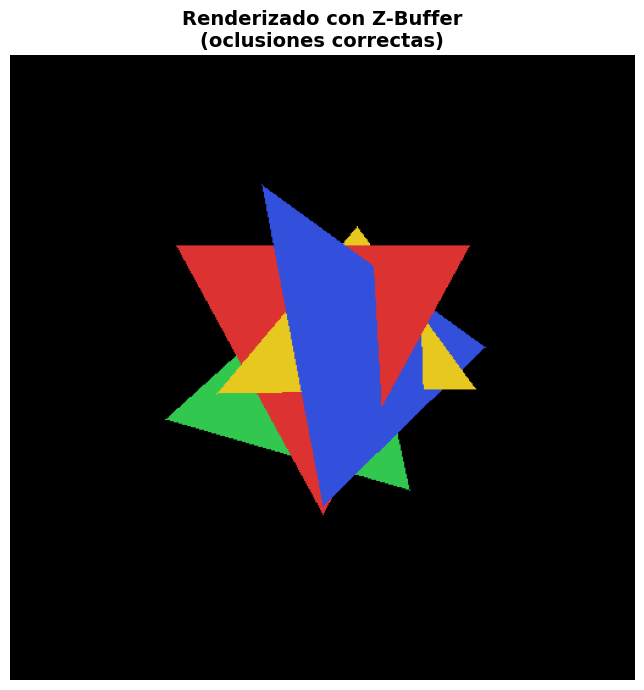

In [21]:
fig, ax = plt.subplots(figsize=(7, 7))
ax.imshow(zbuffer_result)
ax.set_title("Renderizado con Z-Buffer\n(oclusiones correctas)", fontsize=14, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.savefig('zbuffer_result.png', dpi=150, bbox_inches='tight')
plt.show()


---
## Sección 3 — Comparación lado a lado: con/sin Z-buffer

Renderizamos la **misma escena** con ambos métodos y medimos la diferencia píxel a píxel.

In [22]:
# ─── Escena con oclusión obvia para comparación ─────────────────────────────
comparison_scene = [
    # Triángulo ROJO — más cercano (z pequeño)
    ([(-0.5, -0.5, 2.0), (0.5, -0.5, 2.0), (0.0,  0.5, 2.0)], (220, 60, 60),  "Rojo (cercano z=2)"),
    # Triángulo AZUL — más lejano, solapado con el rojo
    ([(-0.3, -0.4, 3.0), (0.7, -0.4, 3.0), (0.2,  0.6, 3.0)], (60, 80, 220),  "Azul (lejano z=3)"),
    # Triángulo VERDE — fondo más lejano
    ([(-0.8,  0.4, 4.0), (0.1, -0.8, 4.0), (0.9,  0.4, 4.0)], (60, 190, 80),  "Verde (fondo z=4)"),
]

# Renderizar con painter (ORDEN INCORRECTO: más cercano primero → luego tapado)
def render_painter_wrongorder(triangles, focal_length=500):
    """Painter en orden INVERSO al correcto para mostrar el error claramente."""
    color_buffer = np.zeros((HEIGHT, WIDTH, 3), dtype=np.uint8)
    # Ordenar de más cercano a más lejano (orden incorrecto para Painter)
    sorted_tris = sorted(triangles, key=lambda t: average_z(t[0]), reverse=False)
    for verts3d, color, name in sorted_tris:
        verts2d = project_triangle(verts3d, focal_length)
        rasterize_triangle_painter(color_buffer, verts2d, color)
    return color_buffer

painter_correct   = render_painter(comparison_scene)          # orden correcto
painter_incorrect = render_painter_wrongorder(comparison_scene)  # orden incorrecto
zbuf_img, zbuf_db = render_zbuffer(comparison_scene)           # Z-buffer

  Pintado: Verde (fondo z=4)  (z_avg=4.00)
  Pintado: Azul (lejano z=3)  (z_avg=3.00)
  Pintado: Rojo (cercano z=2)  (z_avg=2.00)


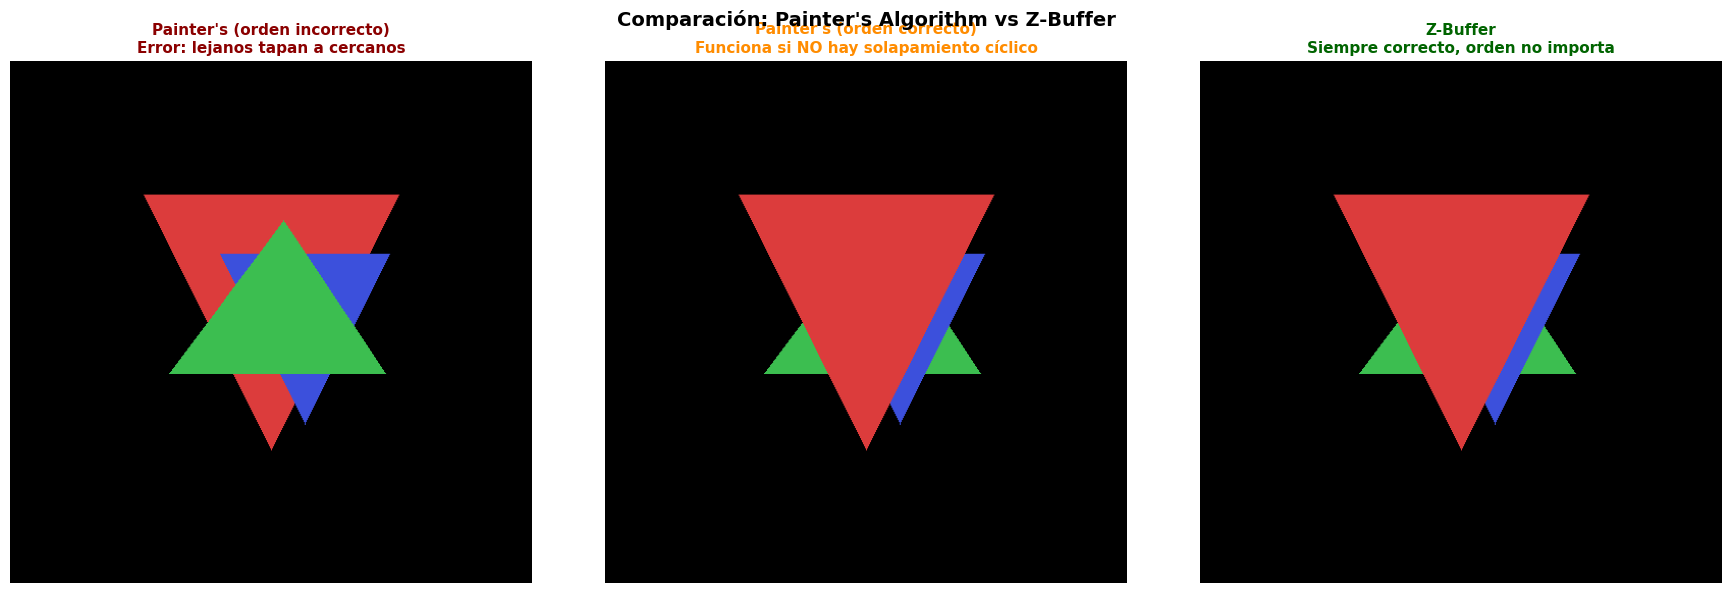

In [23]:
# Visualización lado a lado 
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(painter_incorrect)
axes[0].set_title("Painter's (orden incorrecto)\nError: lejanos tapan a cercanos",
                  fontsize=11, fontweight='bold', color='darkred')
axes[0].axis('off')

axes[1].imshow(painter_correct)
axes[1].set_title("Painter's (orden correcto)\nFunciona si NO hay solapamiento cíclico",
                  fontsize=11, fontweight='bold', color='darkorange')
axes[1].axis('off')

axes[2].imshow(zbuf_img)
axes[2].set_title("Z-Buffer\nSiempre correcto, orden no importa",
                  fontsize=11, fontweight='bold', color='darkgreen')
axes[2].axis('off')

fig.suptitle("Comparación: Painter's Algorithm vs Z-Buffer",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('comparison_side_by_side.png', dpi=150, bbox_inches='tight')
plt.show()

DIFERENCIA respecto al Z-buffer (ground truth)
-------------------------------------------------------
Painter incorrecto — píxeles erróneos: 15,837 / 262,144 (6.0%)
Painter correcto   — píxeles erróneos: 0 / 262,144 (0.0%)

✓ Painter correcto = 0 errores: resultado ESPERADO y CORRECTO.
  Para escenas SIN solapamiento cíclico, el Painter's Algorithm
  back-to-front produce exactamente el mismo resultado que el Z-buffer.
  El problema aparece solo cuando hay solapamiento cíclico (ver Sección 1.4).

→ El Z-buffer siempre produce el resultado correcto
  independientemente del orden de los triángulos.


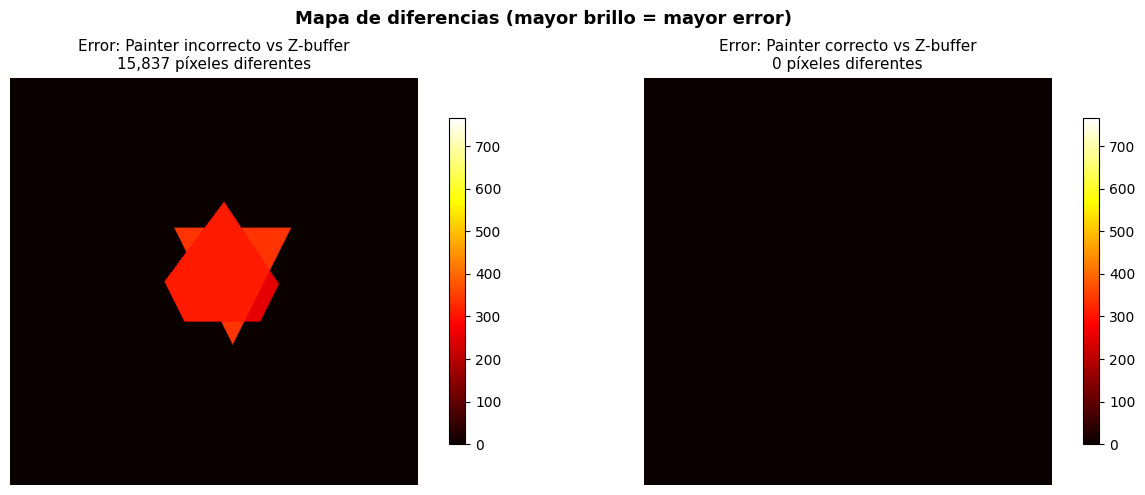

In [24]:
# Medir diferencia entre painter incorrecto y Z-buffer 
diff_incorrect = np.abs(painter_incorrect.astype(int) - zbuf_img.astype(int))
diff_correct   = np.abs(painter_correct.astype(int)   - zbuf_img.astype(int))

pixels_error_incorrect = np.any(diff_incorrect > 5, axis=2).sum()
pixels_error_correct   = np.any(diff_correct   > 5, axis=2).sum()
total_pixels = WIDTH * HEIGHT

print("DIFERENCIA respecto al Z-buffer (ground truth)")
print("-" * 55)
print(f"Painter incorrecto — píxeles erróneos: "
      f"{pixels_error_incorrect:,} / {total_pixels:,} "
      f"({100*pixels_error_incorrect/total_pixels:.1f}%)")
print(f"Painter correcto   — píxeles erróneos: "
      f"{pixels_error_correct:,} / {total_pixels:,} "
      f"({100*pixels_error_correct/total_pixels:.1f}%)")
print()
if pixels_error_correct == 0:
    print("✓ Painter correcto = 0 errores: resultado ESPERADO y CORRECTO.")
    print("  Para escenas SIN solapamiento cíclico, el Painter's Algorithm")
    print("  back-to-front produce exactamente el mismo resultado que el Z-buffer.")
    print("  El problema aparece solo cuando hay solapamiento cíclico (ver Sección 1.4).")
print()
print("→ El Z-buffer siempre produce el resultado correcto")
print("  independientemente del orden de los triángulos.")

# Visualizar mapa de diferencias
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
im0 = axes[0].imshow(diff_incorrect.sum(axis=2), cmap='hot', vmin=0, vmax=255*3)
axes[0].set_title(f"Error: Painter incorrecto vs Z-buffer\n"
                  f"{pixels_error_incorrect:,} píxeles diferentes", fontsize=11)
axes[0].axis('off')
plt.colorbar(im0, ax=axes[0], shrink=0.8)

im1 = axes[1].imshow(diff_correct.sum(axis=2), cmap='hot', vmin=0, vmax=255*3)
axes[1].set_title(f"Error: Painter correcto vs Z-buffer\n"
                  f"{pixels_error_correct:,} píxeles diferentes", fontsize=11)
axes[1].axis('off')
plt.colorbar(im1, ax=axes[1], shrink=0.8)

fig.suptitle("Mapa de diferencias (mayor brillo = mayor error)",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('difference_map.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Conclusiones del Notebook 1

| Método | Ventaja | Limitación |
|---|---|---|
| **Painter's Algorithm** | Simple, no requiere memoria extra | Falla con solapamiento cíclico; necesita ordenar triángulos |
| **Z-Buffer** | Siempre correcto; orden de renderizado no importa | Requiere memoria extra O(WxH); problemas de precisión con float |

El **Notebook 2** analiza en profundidad la visualización del depth buffer y los problemas de precisión numérica.